In [94]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [95]:
# Veri setini yükle
data = pd.read_csv("dataset/penguins.csv")

# 'sex' sütununu encode et
data['sex'] = data['sex'].map({'MALE': 1, 'FEMALE': 0})

# Eksik veya tanınmayan değerleri 'sex' sütunundan kaldır
data = data.dropna(subset=['sex'])

# 'sex' sütununu integer'a çevir
data['sex'] = data['sex'].astype(int)

# Sayısal sütunları tanımla
numeric_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Sayısal sütunları sayısal değerlere dönüştür
data.loc[:, numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Eksik sayısal değerleri kaldır
data = data.dropna(subset=numeric_columns)

# Aykırı değerleri IQR yöntemiyle tespit ve temizle
Q1 = data[numeric_columns].quantile(0.5)
Q3 = data[numeric_columns].quantile(0.95)
IQR = Q3 - Q1
data = data[~((data[numeric_columns] < (Q1 - 1.5 * IQR)) | (data[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]

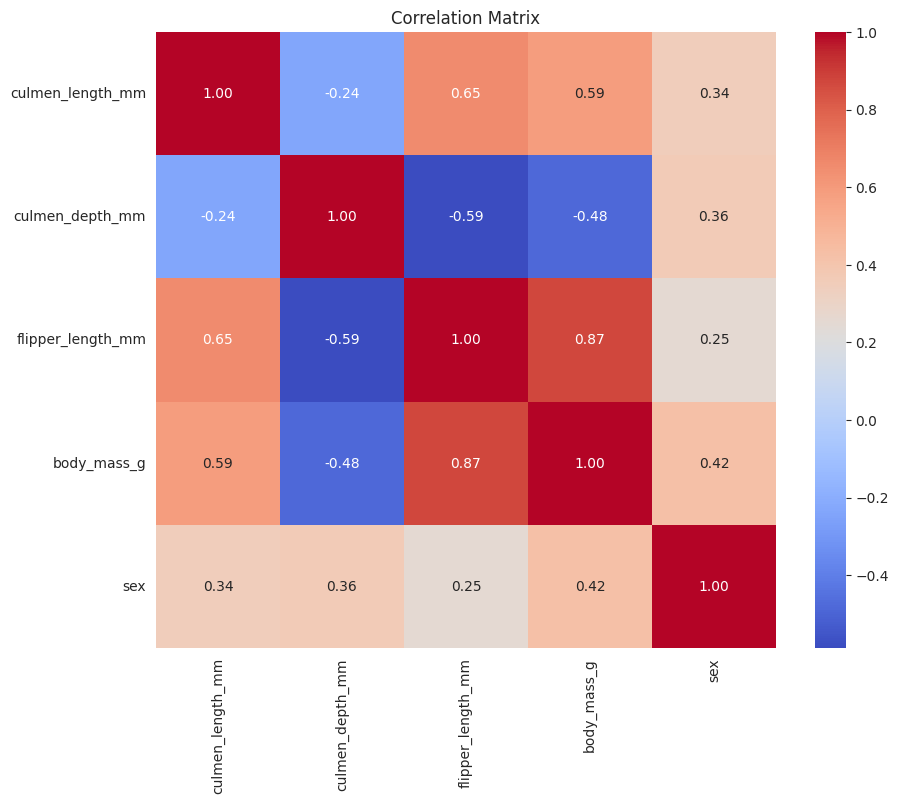

Selected Features: Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex'],
      dtype='object')


In [96]:
# Korelasyon matrisini hesapla
correlation_matrix = data.corr()

# Korelasyon matrisini görselleştir
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Yüksek korelasyonlu özellikleri belirle (örneğin, 0.9 üzeri)
threshold = 0.9
high_corr_features = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname = correlation_matrix.columns[i]
            high_corr_features.add(colname)

# Yüksek korelasyonlu özellikleri kaldır
data = data.drop(columns=high_corr_features)

# Seçilen özellikleri kontrol et
print("Selected Features:", data.columns)

# Veriyi standardize et
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

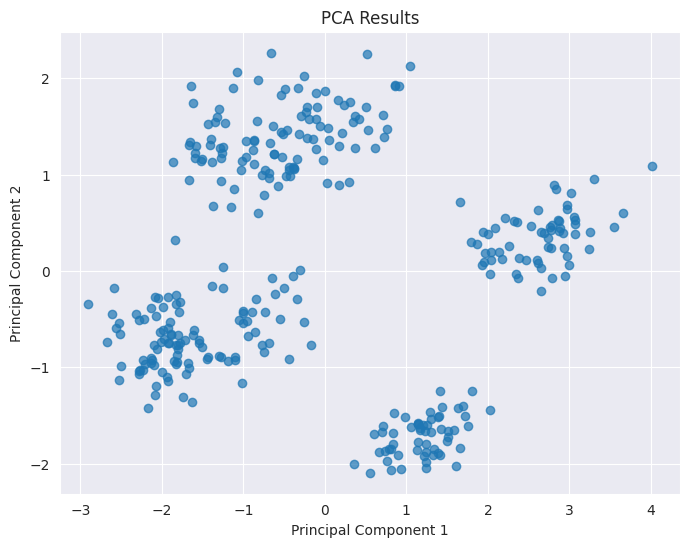

In [97]:
# PCA ile boyut azaltma
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# PCA sonuçlarını görselleştir
plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.7)
plt.title("PCA Results")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

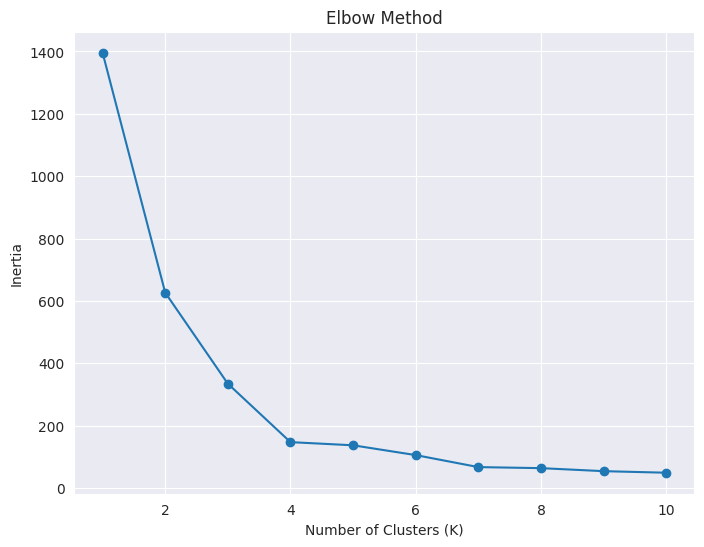

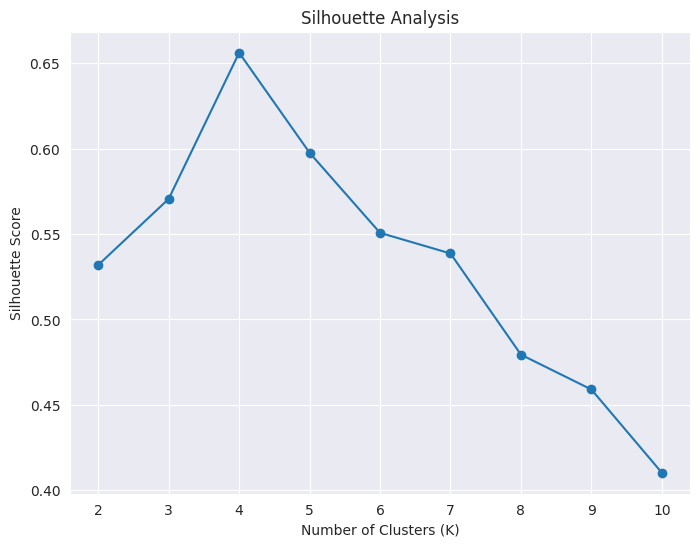

In [98]:
# Elbow Method
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_pca)
    inertia.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Silhouette Analysis
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):  # Silhouette score is not defined for k=1
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(data_pca)
    score = silhouette_score(data_pca, clusters)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

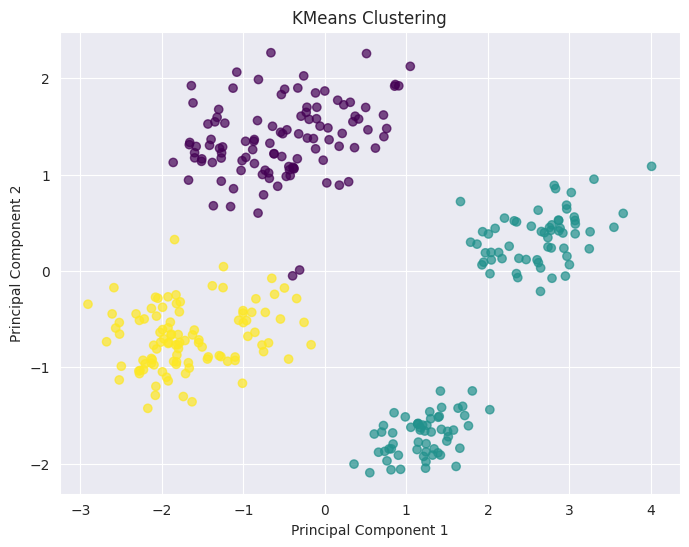

In [99]:
# KMeans ile kümeleme
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(data_pca)

# Kümeleme sonuçlarını görselleştir
plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.title("KMeans Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()